# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [132]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [133]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/flyrank-ml-

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [134]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [135]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [136]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


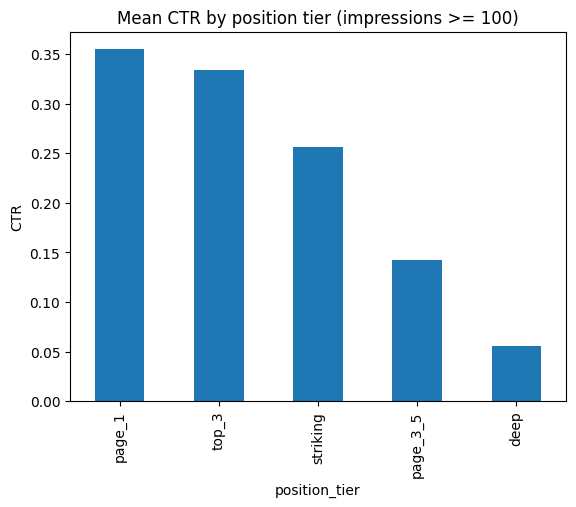

In [137]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [138]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [139]:
# Your discovery here
#Task 1: Discovery A(Redo but with impression is greater than 0)
df_visible = df[df['impressions_90d'] > 0]
corr = df_visible["search_volume"].corr(df_visible["impressions_90d"])
print(f"The correlation between search_volume and impression in 90 days greater than 0 is : {corr:.3f}")
print(f"Findings: ")
print(f"Remvoing low impressions has no impact on correlation still, and still has a near zero effect, search volume is not a good prediction of traffic")

The correlation between search_volume and impression in 90 days greater than 0 is : 0.001
Findings: 
Remvoing low impressions has no impact on correlation still, and still has a near zero effect, search volume is not a good prediction of traffic


In [140]:
#Task 2; Discovery B(which content-type has the worst ctr for the same position_tier"
#First check unique values for position and content_type
print("unique values for position tier", df["position_tier"].unique())
print("unique values for content_type", df["content_type"].unique())

unique values for position tier ['striking' 'page_3_5' 'page_1' 'top_3' 'deep']
unique values for content_type ['keyword article' 'feedly article' 'comparison article']


In [141]:
#Then we groubpy ctr, to find which content_type has the worst ctr for each position tier"
cont_pos_group = df.groupby(["content_type", "position_tier"])["ctr"].mean().sort_values()
#get grouping for each position tier
striking_group = cont_pos_group.xs('striking', level='position_tier')
page1_group = cont_pos_group.xs('page_1', level='position_tier')
page_3_5_group = cont_pos_group.xs('page_3_5', level='position_tier')
top_3_group = cont_pos_group.xs('top_3', level="position_tier")
deep_group = cont_pos_group.xs('deep', level="position_tier")

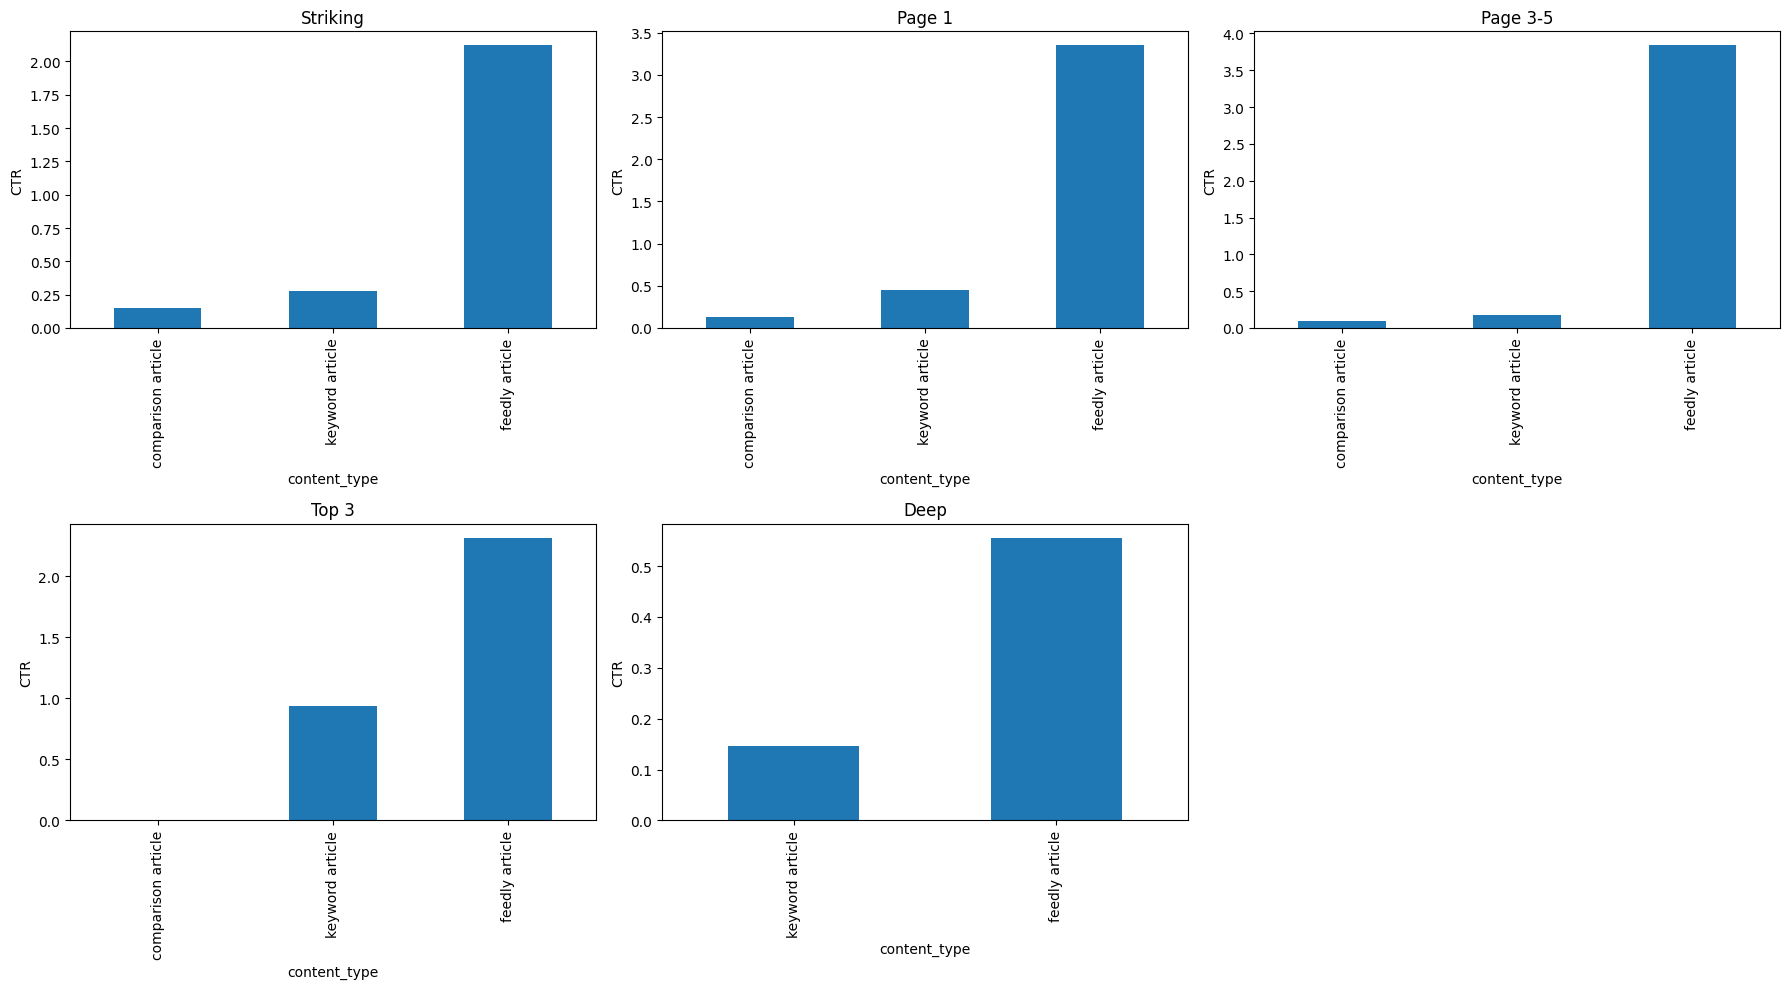

In [142]:
#Plot the values
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

ax = axes.flatten()

striking_group.plot(kind="bar", title="Striking", ylabel="CTR", ax=ax[0])
page1_group.plot(kind="bar", title="Page 1", ylabel="CTR", ax=ax[1])
page_3_5_group.plot(kind="bar", title="Page 3-5", ylabel="CTR", ax=ax[2])
top_3_group.plot(kind="bar", title="Top 3", ylabel="CTR", ax=ax[3])
deep_group.plot(kind="bar", title="Deep", ylabel="CTR", ax=ax[4])

ax[5].axis('off')

plt.tight_layout()
plt.show()


In [143]:
print("based on findings on the data, the worst CTR for each position tier")
print("striking: comparison article")
print("page 1: comparison article")
print("page 3-5: comparion article")
print("top3: comparison article")
print("deep: keyword aricle")
print("comparison article has the worst CTR except for deep, likely because it doesn't rank enough, so lower data")

based on findings on the data, the worst CTR for each position tier
striking: comparison article
page 1: comparison article
page 3-5: comparion article
top3: comparison article
deep: keyword aricle
comparison article has the worst CTR except for deep, likely because it doesn't rank enough, so lower data


In [144]:
#Task 3: Another belief test
print(f"checking datat types before: correlation")
print(df["content_age_days"].dtype)
print(df["trend_direction"].dtype)


checking datat types before: correlation
int64
object


In [145]:
df["trend_direction"].unique()

array(['down', 'stable', 'new', 'up', 'flat'], dtype=object)

In [146]:
#New and stable seems  confusing, let's find which ranks higher

df.groupby(["trend_direction"])[["trend_pct", "impressions_90d"]].mean()

,trend_pct,impressions_90d
trend_direction,,
down,-58.113830,4919.097466
flat,NaN,20.738715
new,NaN,164.131038
stable,-3.185944,9213.615230
up,190.673997,4716.081130


In [147]:

trend_map = {'new': 0, 'down': 1, 'stable': 2, 'flat': 3, 'up': 4}
df["trend_direction_value"] = df["trend_direction"].map(trend_map)




In [148]:
age_days_trend_corr = df["content_age_days"].corr(df["trend_direction_value"])
print(f"the correlation between content_age_days and the trend direction is: {age_days_trend_corr:.2f}")
print(f"It has a positive but weak correlation and small predictive power")
print(f"Therefore it has positive relationship")

the correlation between content_age_days and the trend direction is: 0.15
It has a positive but weak correlation and small predictive power
Therefore it has positive relationship


In [149]:
#Find dtypes for other correlation, we know ctr can be used(it was used it before)
print(df["avg_position"].dtypes)

float64


In [150]:
avg_pos_ctr_corr = df["avg_position"].corr(df["ctr"])
print(f"correlation between avg_position and ctr is: {avg_pos_ctr_corr:.2f}")
print("It has a negative but near-zero correlation")
print("Therefore there is negative relationship but the correlation is near zero")

correlation between avg_position and ctr is: -0.07
It has a negative but near-zero correlation
Therefore there is negative relationship but the correlation is near zero


### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.